# **LAB Deep Learning Session 3** (Fri, 25/09/2026)

In [ ]:
# # Uncomment jika pakai google colab
# from google.colab import files
# import zipfile
# import os

# # 1. Upload file zip dari laptop
# print("Pilih file ZIP dataset:")
# uploaded = files.upload()

# zip_name = list(uploaded.keys())[0]
# extract_dir = "/content/raw_dataset"

# # 2. Ekstrak
# print(f"Mengekstrak {zip_name}...")
# with zipfile.ZipFile(zip_name, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# # 3. Hapus file zip asli agar storage disk Colab lebih hemat
# os.remove(zip_name)

# print("Selesai! Struktur dataset:")
# print(os.listdir(extract_dir))

In [2]:
# Import Library
import tensorflow as tf
import numpy as np
import keras.utils
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt

# **Load Dataset**

In [3]:
TINGGI, LEBAR = 102, 135
data_path = "/content/raw_dataset/dataset" # sesuaikan path datasetnya
kelas = sorted(os.listdir(data_path))
print("Class:", kelas)

x , y = [], []
for label, nama_kelas in enumerate(kelas):
  folder = os.path.join(data_path, nama_kelas) # -> dataset/boot, dataset/shoe, dataset/sandal
  print(folder)
  for nama_file in os.listdir(folder):
    if nama_file.endswith("Thumbs.db"):
      continue

    gambar = keras.utils.load_img(os.path.join(folder, nama_file), target_size=(TINGGI, LEBAR))

    x.append(np.array(gambar)) # x simpan gambar
    y.append(label) # y simpan class / title

x = np.array(x)
y = np.array(y)

print("Jumlah Gambar:", len(x))
print(x.shape) # Shape -> (jumlah gambar, height, width, color type)

Class: ['Boot', 'Sandal', 'Shoe']
/content/raw_dataset/dataset/Boot
/content/raw_dataset/dataset/Sandal
/content/raw_dataset/dataset/Shoe
Jumlah Gambar: 15000
(15000, 102, 135, 3)


# **Normalize and One HOT Encoding**

In [4]:
x = x.astype('float32') / 255

# 80% training, 10% validation, 10% testing
x_train, x_sisa, y_train, y_sisa = train_test_split(x, y, test_size=0.2, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_sisa, y_sisa, test_size=0.5, random_state=42)

# One Hot Encoding -> [1, 0, 0] -> boot
#                     [0, 1, 0] -> sandal
#                     [0, 0, 1] -> shoe

y_train = keras.utils.to_categorical(y_train, num_classes=len(kelas))
y_val = keras.utils.to_categorical(y_val, num_classes=len(kelas))
y_test = keras.utils.to_categorical(y_test, num_classes=len(kelas))

print("Data Training:", len(x_train))
print("Data Validation:", len(x_val))
print("Data Testing:", len(x_test))

Data Training: 12000
Data Validation: 1500
Data Testing: 1500


# **Model Making**

In [5]:
model = keras.Sequential([
    keras.Input(shape=(TINGGI, LEBAR, 3)),

    keras.layers.Conv2D(6,(5,5),activation='relu'),
    # angka 6 -> akan jadi berapa gambar (ubah jadi 6 gambar)
    # (5,5) = kernel 5x5, semakin kecil kernel semakin detail gambar yang dianalisa
    # param 1 -> filter gambar
    # param 2 -> kerel size
    # param 3 -> Activation Func
    keras.layers.AveragePooling2D(pool_size=(2,2)),

    keras.layers.Conv2D(16,(5,5),activation='relu'), # filter gambar 16 = makin banyak, convolutional ngebagi filter sampe detail
    keras.layers.AveragePooling2D(pool_size=(2,2)),
    keras.layers.Flatten(),

    # dense kelipatan 2, lebih bagus, yang convolutional juga bagus kelipatam 2, 2^2
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(len(kelas),activation='softmax')

])

In [ ]:
model.summary()

# total params aslinya 1.4 juta

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 131, 6)     │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 49, 65, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 61, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 22, 30, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10560)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,351,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,363,131 (5.20 MB)

 Trainable params: 1,363,131 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

# **Training**

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10, validation_data=(x_val, y_val)
)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.8261 - loss: 0.4440 - val_accuracy: 0.9360 - val_loss: 0.1931
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9372 - loss: 0.1752 - val_accuracy: 0.9500 - val_loss: 0.1415
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9525 - loss: 0.1299 - val_accuracy: 0.9533 - val_loss: 0.1389
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9677 - loss: 0.0903 - val_accuracy: 0.9620 - val_loss: 0.1091
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9779 - loss: 0.0635 - val_accuracy: 0.9660 - val_loss: 0.1245
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9795 - loss: 0.0577 - val_accuracy: 0.9420 - val_loss: 0.1717
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9813 - loss: 0.0508 - val_accuracy: 0.9707 - val_loss: 0.1037
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9887 - loss: 0.0330 - val_accuracy: 0.9720 - 

# **Plotting**

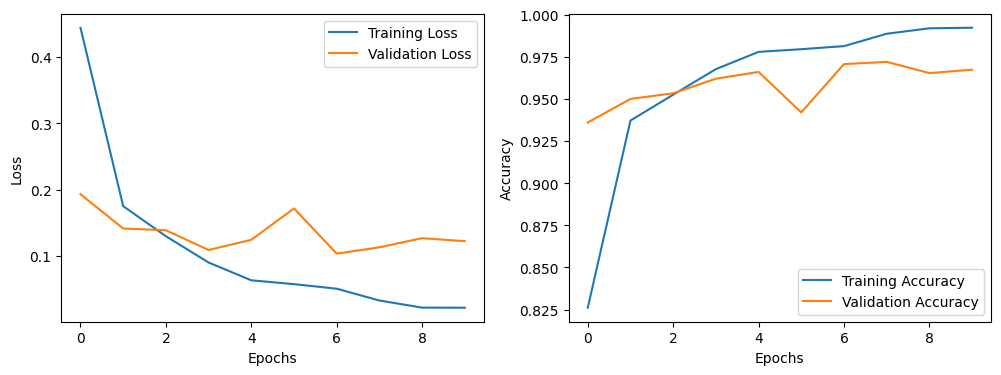

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9713 - loss: 0.1097
Accuracy 0.9713333249092102
[2 1 2 ... 2 2 1]
[2 1 2 ... 2 2 1]


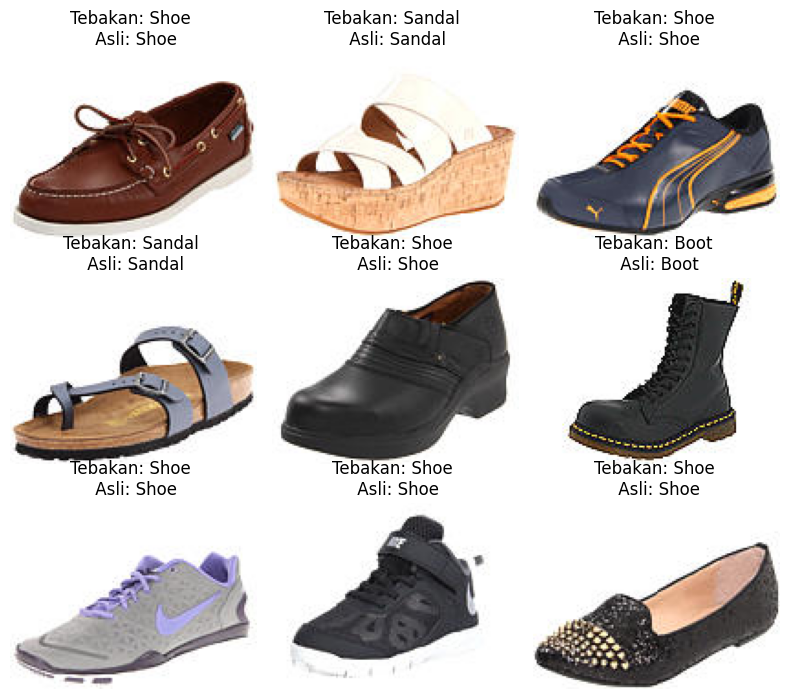

In [9]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Accuracy", accuracy)

predictions = model.predict(x_test, verbose = 0)
tebakan = np.argmax(predictions, axis=1)
asli = np.argmax(y_test, axis=1)
print(tebakan)
print(asli)

plt.figure(figsize=(8,7))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_test[i])
  plt.title(f"Tebakan: {kelas[tebakan[i]]} \n Asli: {kelas[asli[i]]}")
  plt.axis('off')

plt.tight_layout()
plt.show()